# 🏥 Notebook 04: Agent Communication & Resource Requests

Welcome to the next level of our simulation! So far, we've created a world where people (`PersonAgent`s) can get sick and recover. Now, we're introducing a critical piece of infrastructure: **Hospitals**.

**Today's Goals:**
1.  **Create a `HospitalAgent`**: A new type of agent that is stationary and has a limited number of beds.
2.  **Upgrade `PersonAgent`**: Give them the intelligence to find the nearest hospital when they get sick.
3.  **Model System Strain**: See what happens when all the hospital beds are full.
4.  **Implement Basic "Communication"**: A hospital will be able to signal that it is full, which other agents can observe. This is the first step towards true agent communication.

In [2]:
# All our standard imports
import mesa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Plotting settings for better visuals
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported. Ready to define our new, more intelligent agents!")
print(f"Mesa version: {mesa.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

Libraries imported. Ready to define our new, more intelligent agents!
Mesa version: 2.3.2
NumPy version: 2.3.2
Pandas version: 2.3.1


## Step 1: Creating the HospitalAgent

First, we need to define what a hospital is in our simulation. It's an agent, just like a person, but with a few key differences:
* It **doesn't move**.
* It has a **capacity** (a limited number of beds).
* It keeps track of its **current patients**.
* It can communicate its status (e.g., if it's full).

In [3]:
class HospitalAgent(mesa.Agent):
    """Represents a hospital with limited capacity."""
    
    def __init__(self, unique_id, model, capacity=25):
        super().__init__(unique_id, model)
        self.capacity = capacity
        self.patients = 0 # Number of patients currently admitted

    @property
    def is_full(self):
        """A property to easily check if the hospital is at capacity."""
        return self.patients >= self.capacity
        
    def admit_patient(self):
        """Admits one patient, if space is available."""
        if not self.is_full:
            self.patients += 1
            return True # Admission successful
        return False # Admission failed, hospital is full

    def discharge_patient(self):
        """Discharges one patient."""
        if self.patients > 0:
            self.patients -= 1
    
    def step(self):
        # Hospitals are passive in this model; they don't have a per-step action.
        # Their state is changed by PersonAgents interacting with them.
        pass

print("✅ HospitalAgent class defined successfully.")

✅ HospitalAgent class defined successfully.


## Step 2: Upgrading the PersonAgent

Now we make our `PersonAgent` smarter. We need to add logic for them to handle being hospitalized.

**New `PersonAgent` Logic:**
1.  When an agent becomes **Infected**, their new goal is to find a hospital.
2.  They will **search for the nearest hospital** that is not full.
3.  If they find one, they will **move towards it** each step.
4.  Once they reach the hospital, they will become **`HOSPITALIZED`**. A hospitalized agent stops moving.
5.  While hospitalized, they will recover at a **faster rate**.
6.  If they can't find any hospital with free beds, they are considered **`UNTREATED`**. They recover at the normal (slower) rate while continuing to move and infect others.

In [14]:
# We need a more detailed state class to track hospitalization.
class State:
    SUSCEPTIBLE = 0
    INFECTED_UNTREATED = 1 # Infected but not in a hospital
    HOSPITALIZED = 2       # Infected and in a hospital bed
    RECOVERED = 3

class PersonAgent(mesa.Agent):
    """A person with health status and hospitalization logic."""
    
    def __init__(self, unique_id, model, recovery_rate, hospitalized_recovery_rate):
        super().__init__(unique_id, model)
        self.state = State.SUSCEPTIBLE
        self.recovery_rate = recovery_rate
        self.hospitalized_recovery_rate = hospitalized_recovery_rate
        self.hospital_id = None # To track which hospital they are admitted to

    def step(self):
        # Behavior depends on the agent's state
        if self.state == State.INFECTED_UNTREATED:
            self.try_to_get_hospitalized()
            self.infect_neighbors()
            self.try_to_recover(self.recovery_rate)
        
        elif self.state == State.HOSPITALIZED:
            # If hospitalized, recovery chance is higher, but they don't move or infect.
            self.try_to_recover(self.hospitalized_recovery_rate)

        # Only non-hospitalized agents move
        elif self.state == State.SUSCEPTIBLE or self.state == State.RECOVERED:
            self.move()

    def try_to_recover(self, rate):
        """Attempt to recover from the infection."""
        if self.random.random() < rate:
            # If they were in a hospital, we need to free up the bed
            if self.state == State.HOSPITALIZED:
                hospital = next((agent for agent in self.model.schedule.agents if isinstance(agent, HospitalAgent) and agent.unique_id == self.hospital_id), None)
                if hospital:
                    hospital.discharge_patient()
                self.hospital_id = None

            self.state = State.RECOVERED
            
    def try_to_get_hospitalized(self):
        """Find the nearest available hospital and move towards it."""
        # Find all hospital agents
        hospitals = self.model.hospitals
        
        # Filter for hospitals that are not full
        available_hospitals = [h for h in hospitals if not h.is_full]
        
        if not available_hospitals:
            # No beds available anywhere, remain untreated
            return

        # Find the closest available hospital
        closest_hospital = min(available_hospitals, key=lambda h: self.distance_to(h))
        
        # Are we at the hospital?
        if self.pos == closest_hospital.pos:
            # Try to get admitted
            if closest_hospital.admit_patient():
                self.state = State.HOSPITALIZED
                self.hospital_id = closest_hospital.unique_id
        else:
            # Move towards the hospital
            self.move_towards(closest_hospital)

    def move(self):
        """Default random movement."""
        possible_steps = self.model.grid.get_neighborhood(self.pos, moore=True)
        new_position = self.random.choice(possible_steps)
        self.model.grid.move_agent(self, new_position)
        
    def move_towards(self, target_agent):
        """Move one step closer to a target agent's position."""
        dx = target_agent.pos[0] - self.pos[0]
        dy = target_agent.pos[1] - self.pos[1]

        # Move horizontally or vertically towards the target
        if abs(dx) > abs(dy):
            new_x = self.pos[0] + np.sign(dx)
            new_y = self.pos[1]
        else:
            new_x = self.pos[0]
            new_y = self.pos[1] + np.sign(dy)
        
        # Ensure the new position is within the grid
        new_pos = (max(0, min(self.model.grid.width - 1, new_x)),
                   max(0, min(self.model.grid.height - 1, new_y)))
                   
        self.model.grid.move_agent(self, new_pos)

    def distance_to(self, other_agent):
        """Calculate Manhattan distance to another agent."""
        return abs(self.pos[0] - other_agent.pos[0]) + abs(self.pos[1] - other_agent.pos[1])

    def infect_neighbors(self):
        # Same infection logic as before
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        for other in cellmates:
            if isinstance(other, PersonAgent) and other.state == State.SUSCEPTIBLE:
                if self.random.random() < self.model.transmission_rate:
                    # When a susceptible person gets infected, their state is now UNTREATED
                    other.state = State.INFECTED_UNTREATED

print("✅ PersonAgent class upgraded with hospitalization logic.")

✅ PersonAgent class upgraded with hospitalization logic.


## Step 3: Upgrading the Main Model

Now we must update the `EpidemicModel` to manage our new types of agents and their more complex interactions.

**New `EpidemicModel` Logic:**
1.  Accept new parameters for the number of hospitals and their capacity.
2.  Create and place the **`HospitalAgent`s first** at fixed locations.
3.  Create and place the **`PersonAgent`s**, passing them the different recovery rates.
4.  Update the **`DataCollector`** to track our new, more detailed agent states (`HOSPITALIZED`, `INFECTED_UNTREATED`) and the overall hospital occupancy.

In [15]:
class EpidemicModel(mesa.Model):
    """The main model that manages hospitals and people."""
    
    def __init__(self, N=100, width=50, height=50, transmission_rate=0.3, 
                 recovery_rate=0.1, hospitalized_recovery_rate=0.3, 
                 p_initial_infected=0.1, num_hospitals=5, hospital_capacity=20):
        
        super().__init__()
        self.num_agents = N
        self.transmission_rate = transmission_rate
        self.grid = mesa.space.MultiGrid(width, height, True)
        self.schedule = mesa.time.RandomActivation(self)
        self.running = True
        self.hospitals = [] # A list to easily access hospital agents

        # --- Create Hospital Agents ---
        hospital_id_start = N # Ensure unique IDs don't clash with people
        for i in range(num_hospitals):
            hid = hospital_id_start + i
            h = HospitalAgent(hid, self, hospital_capacity)
            self.hospitals.append(h)
            self.schedule.add(h)
            # Place hospitals at random, fixed locations
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(h, (x, y))

        # --- Create Person Agents ---
        for i in range(self.num_agents):
            a = PersonAgent(i, self, recovery_rate, hospitalized_recovery_rate)
            self.schedule.add(a)
            x = self.random.randrange(self.grid.width)
            y = self.random.randrange(self.grid.height)
            self.grid.place_agent(a, (x, y))
            if self.random.random() < p_initial_infected:
                a.state = State.INFECTED_UNTREATED

        # --- Data Collection ---
        self.datacollector = mesa.DataCollector(
            model_reporters={
                "Susceptible": lambda m: self.count_states(m, PersonAgent, State.SUSCEPTIBLE),
                "Infected (Untreated)": lambda m: self.count_states(m, PersonAgent, State.INFECTED_UNTREATED),
                "Hospitalized": lambda m: self.count_states(m, PersonAgent, State.HOSPITALIZED),
                "Recovered": lambda m: self.count_states(m, PersonAgent, State.RECOVERED),
                "Total Hospital Occupancy": lambda m: sum(h.patients for h in m.hospitals)
            }
        )
    
    @staticmethod
    def count_states(model, agent_type, state):
        """Helper function to count agents of a specific type in a given state."""
        return sum(1 for a in model.schedule.agents if isinstance(a, agent_type) and a.state == state)

    def step(self):
        self.datacollector.collect(self)
        self.schedule.step()
        # Stop if no more infected people (either hospitalized or untreated)
        if self.count_states(self, PersonAgent, State.INFECTED_UNTREATED) == 0 and \
           self.count_states(self, PersonAgent, State.HOSPITALIZED) == 0:
            self.running = False

print("✅ EpidemicModel class upgraded to manage both hospitals and people.")

✅ EpidemicModel class upgraded to manage both hospitals and people.


## Step 4: Running the Simulation and Visualizing the Strain

Now, let's run our most complex simulation yet! We will set parameters for our city's healthcare system and observe the outcome. The key things to watch for are:
* How many people end up hospitalized versus untreated?
* Does the healthcare system get overwhelmed? At what point do the hospitals fill up completely?

In [24]:
# --- Simulation Parameters ---
POPULATION = 1000
GRID_WIDTH = 40
GRID_HEIGHT = 40
TRANSMISSION_RATE = 0.9      # Increased slightly to create more pressure on the system
RECOVERY_RATE = 0.1        # Recovery without hospital care is slow
HOSPITALIZED_RECOVERY_RATE = 0.125 # Recovery with hospital care is much faster
INITIAL_INFECTED_P = 0.2

# --- Healthcare System Parameters ---
NUM_HOSPITALS = 2
HOSPITAL_CAPACITY = 10
TOTAL_CAPACITY = NUM_HOSPITALS * HOSPITAL_CAPACITY

SIMULATION_STEPS = 200

# --- Create and Run the Model ---
print("Initializing the model with healthcare system...")
model = EpidemicModel(
    N=POPULATION,
    width=GRID_WIDTH,
    height=GRID_HEIGHT,
    transmission_rate=TRANSMISSION_RATE,
    recovery_rate=RECOVERY_RATE,
    hospitalized_recovery_rate=HOSPITALIZED_RECOVERY_RATE,
    p_initial_infected=INITIAL_INFECTED_P,
    num_hospitals=NUM_HOSPITALS,
    hospital_capacity=HOSPITAL_CAPACITY
)

print(f"Running simulation with {NUM_HOSPITALS} hospitals and a total capacity of {TOTAL_CAPACITY} beds...")
for i in range(SIMULATION_STEPS):
    if model.running:
        model.step()
    else:
        print(f"Simulation stopped early at step {i} as there are no more infections.")
        break
print("Simulation complete.")

# --- Get the Data ---
results_df = model.datacollector.get_model_vars_dataframe()# --- Simulation Parameters ---

# POPULATION = 1000
# GRID_WIDTH = 50
# GRID_HEIGHT = 50
# TRANSMISSION_RATE = 0.9      # Increased slightly to create more pressure on the system
# RECOVERY_RATE = 0.05         # Recovery without hospital care is slow
# HOSPITALIZED_RECOVERY_RATE = 0.003 # Recovery with hospital care is much faster
# INITIAL_INFECTED_P = 0.2

# # --- Healthcare System Parameters ---
# NUM_HOSPITALS = 5
# HOSPITAL_CAPACITY = 20
# TOTAL_CAPACITY = NUM_HOSPITALS * HOSPITAL_CAPACITY

# SIMULATION_STEPS = 200

# # --- Create and Run the Model ---
# print("Initializing the model with healthcare system...")
# model = EpidemicModel(
#     N=POPULATION,
#     width=GRID_WIDTH,
#     height=GRID_HEIGHT,
#     transmission_rate=TRANSMISSION_RATE,
#     recovery_rate=RECOVERY_RATE,
#     hospitalized_recovery_rate=HOSPITALIZED_RECOVERY_RATE,
#     p_initial_infected=INITIAL_INFECTED_P,
#     num_hospitals=NUM_HOSPITALS,
#     hospital_capacity=HOSPITAL_CAPACITY
# )

# print(f"Running simulation with {NUM_HOSPITALS} hospitals and a total capacity of {TOTAL_CAPACITY} beds...")
# for i in range(SIMULATION_STEPS):
#     if model.running:
#         model.step()
#     else:
#         print(f"Simulation stopped early at step {i} as there are no more infections.")
#         break
# print("Simulation complete.")

# # --- Get the Data ---
# results_df = model.datacollector.get_model_vars_dataframe()

Initializing the model with healthcare system...
Running simulation with 2 hospitals and a total capacity of 20 beds...
Simulation stopped early at step 82 as there are no more infections.
Simulation complete.


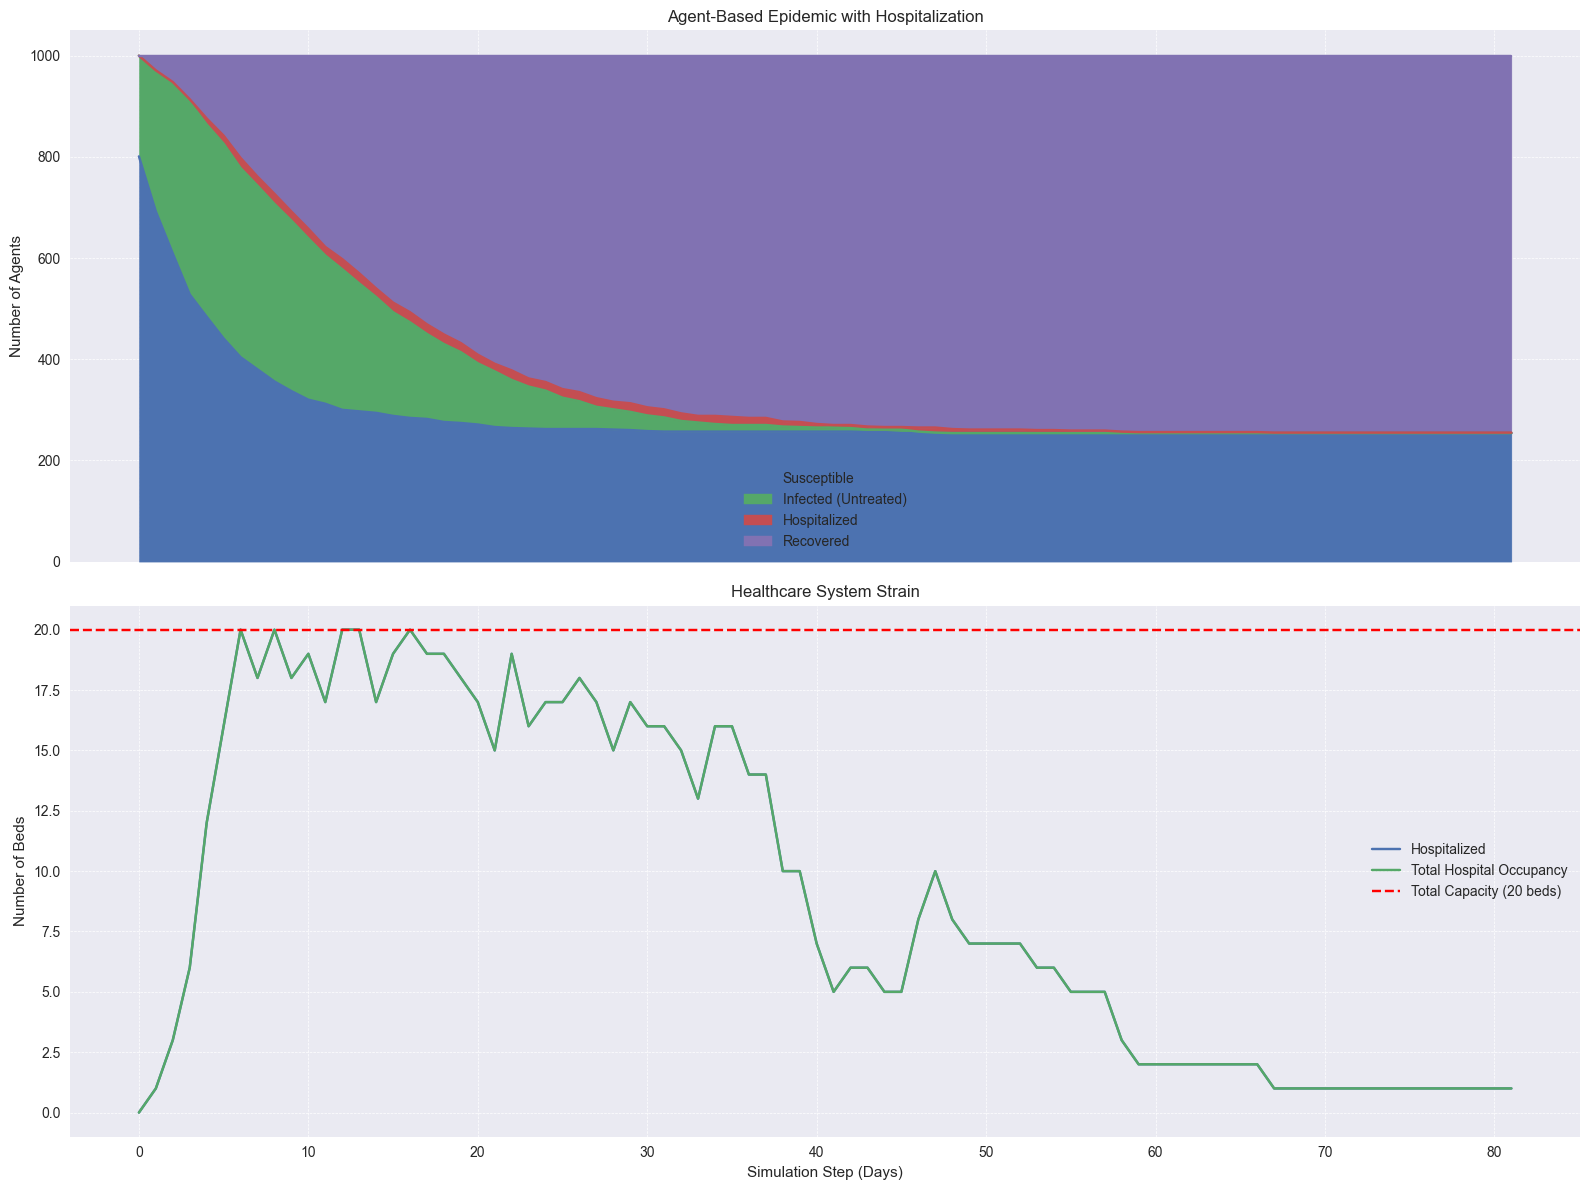


--- Healthcare System Analysis ---
Total hospital capacity: 20 beds
Peak number of patients needing care (untreated + hospitalized): 405
Peak number of patients actually hospitalized: 20
Maximum simultaneous bed occupancy: 20

🚨 CRITICAL: The healthcare system was overwhelmed. All beds were full at peak.


In [25]:
# --- Plotting the Results ---

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Plot 1: Main Epidemic Curves
results_df[["Susceptible", "Infected (Untreated)", "Hospitalized", "Recovered"]].plot(
    ax=ax1,
    kind='area',
    stacked=True,
    title='Agent-Based Epidemic with Hospitalization'
)
ax1.set_ylabel("Number of Agents")
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Plot 2: Healthcare System Strain
results_df[["Hospitalized", "Total Hospital Occupancy"]].plot(
    ax=ax2,
    title='Healthcare System Strain'
)
# Add a line for total capacity
ax2.axhline(y=TOTAL_CAPACITY, color='r', linestyle='--', label=f'Total Capacity ({TOTAL_CAPACITY} beds)')
ax2.set_ylabel("Number of Beds")
ax2.set_xlabel("Simulation Step (Days)")
ax2.legend()
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)


plt.tight_layout()
plt.show()

# --- Print Key Metrics ---
peak_hospitalized = results_df["Hospitalized"].max()
peak_untreated = results_df["Infected (Untreated)"].max()
max_occupancy = results_df["Total Hospital Occupancy"].max()

print("\n--- Healthcare System Analysis ---")
print(f"Total hospital capacity: {TOTAL_CAPACITY} beds")
print(f"Peak number of patients needing care (untreated + hospitalized): {peak_untreated + peak_hospitalized}")
print(f"Peak number of patients actually hospitalized: {peak_hospitalized}")
print(f"Maximum simultaneous bed occupancy: {max_occupancy}")

if max_occupancy >= TOTAL_CAPACITY:
    print("\n🚨 CRITICAL: The healthcare system was overwhelmed. All beds were full at peak.")
else:
    print("\n✅ The healthcare system capacity was sufficient.")